In [ ]:
%pip install -r ../../requirements.txt

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


...


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
from pathlib import Path
import sys

import stim
import sinter
import numpy as np

# Decoder imports
import pymatching
import ldpc
from ldpc.sinter_decoders import SinterBpOsdDecoder
import decoders.sinter_decoders.sinter_unionfind_decoder

# Plotting
import matplotlib.pyplot as plt

ModuleNotFoundError: No module named 'sinter_decoders'

In [2]:
distances = [3, 5,7]
dep_error_rates = np.linspace(1e-4, 1e-2, 20)

# Source: adapted from https://github.com/quantumlib/Stim/blob/01f1aabd0fbc64d6943d42094a4bde96818399bd/doc/getting_started.ipynb

tasks = [
    sinter.Task(
        circuit=stim.Circuit.generated(
            #"surface_code:rotated_memory_z",
            "color_code:memory_xyz",
            rounds=d * 3,
            distance=d,
            before_round_data_depolarization=p, 
            after_clifford_depolarization=p, 
            before_measure_flip_probability=p, 
            after_reset_flip_probability=p
        ),
        json_metadata={'d': d, 'p': p},
    )
    for d in distances
    for p in dep_error_rates
]

In [ ]:
custom_decoders = {
    "bposd": SinterBpOsdDecoder(
        max_iter=10,
        bp_method="ms",
        ms_scaling_factor=0.625,
        schedule="parallel",
        osd_method="osd0",
        osd_order=0,
    ),

    # Union-find decoder for sinter, adapted from https://github.com/quantumgizmos/ldpc/blob/main/src_python/ldpc/sinter_decoders/sinter_bposd_decoder.py
    "union_find": SinterUnionFindDecoder(
        uf_method='False'
    ),
}

collected_stats = sinter.collect(
    num_workers=10,
    tasks=tasks,
    decoders=['pymatching','bposd','union_find'],
    custom_decoders=custom_decoders,
    #max_shots=1_000_000,
    max_shots=10_000,
    max_errors=1000,
)

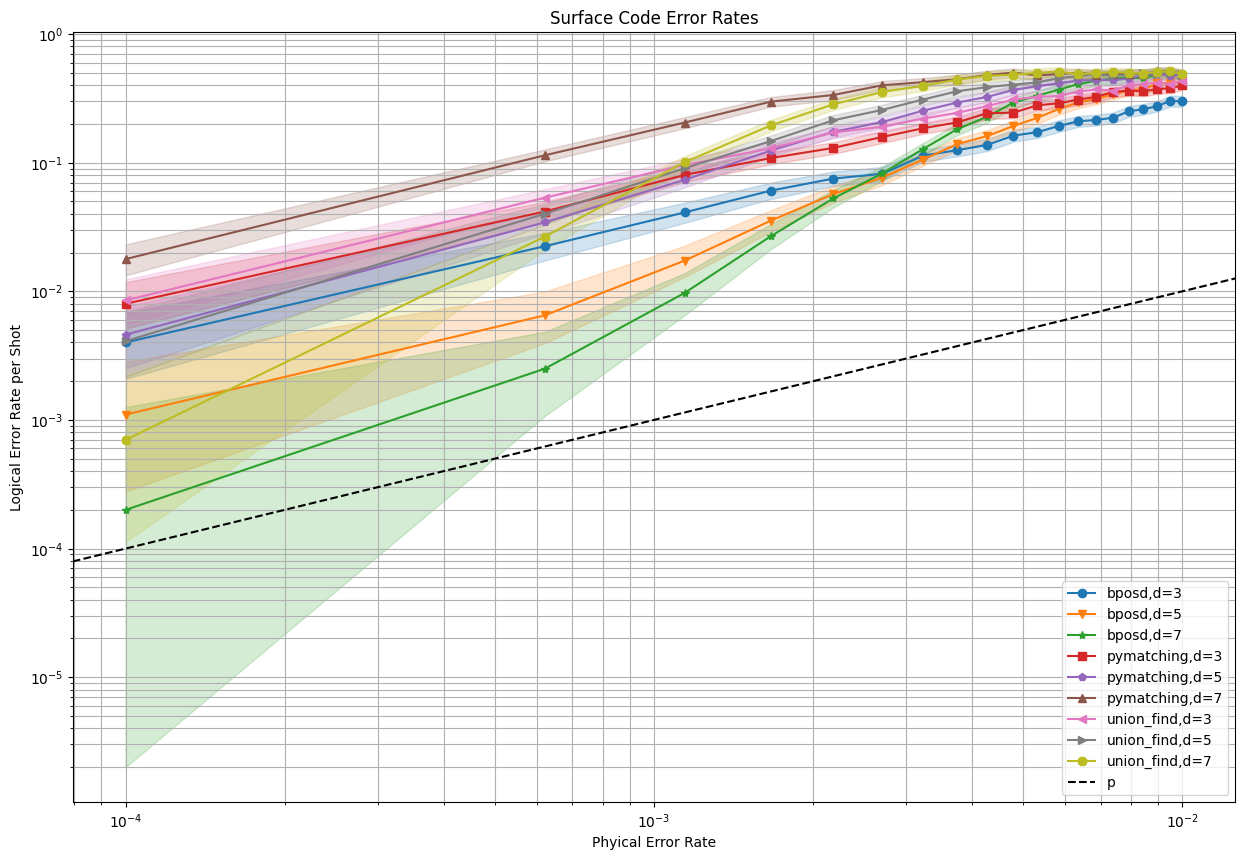

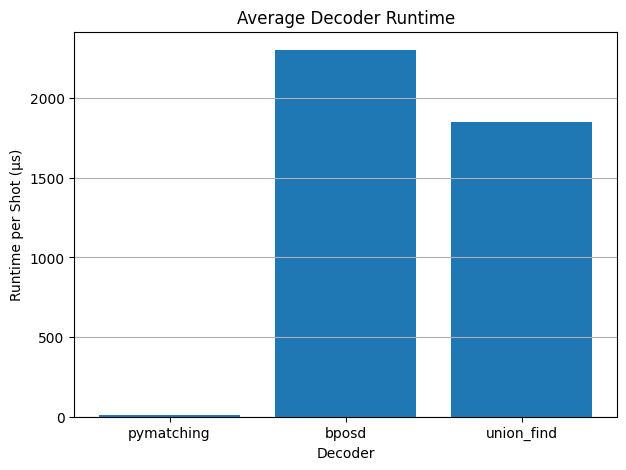

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(15,10))
sinter.plot_error_rate(
    ax=ax,
    stats=collected_stats,
    x_func=lambda stats: stats.json_metadata['p'],
    group_func=lambda stats: f"{stats.decoder},d={stats.json_metadata['d']}",
)
ax.axline((0, 0), slope=1, label='p', linestyle='--', color='black')
ax.loglog()
ax.set_title("Surface Code Error Rates")
ax.set_xlabel("Phyical Error Rate")
ax.set_ylabel("Logical Error Rate per Shot")
ax.grid(which='major')
ax.grid(which='minor')
ax.legend()

decoders = ["pymatching", "bposd", "union_find"]

decoder_times = []
decoder_labels = []

for decoder in decoders:
    total_seconds = 0
    total_shots = 0

    for stat in collected_stats:
        if stat.decoder == decoder:
            total_seconds += stat.seconds
            total_shots += stat.shots

    avg_microseconds_per_shot = 1e6 * total_seconds / total_shots

    decoder_labels.append(decoder)
    decoder_times.append(avg_microseconds_per_shot)

fig, ax = plt.subplots(1, 1, figsize=(7, 5))

ax.bar(decoder_labels, decoder_times)

ax.set_title("Average Decoder Runtime")
ax.set_xlabel("Decoder")
ax.set_ylabel("Runtime per Shot (µs)")
ax.grid(axis="y")
plt.show()